# Laboratorio 1 - Regresión - Aprendizaje de máquina - Grupo 80

**Integrantes:**  
- Juan Diego Quintero Alvarez - 202412750
- Juan Jose Penha Pulido - 202312307

En este laboratorio se aplica el ciclo completo de machine learning para predecir la variable objetivo `temp_max_manana` a partir de variables meteorológicas. El enfoque principal será la exploración, limpieza, preparación de datos y construcción de un modelo de regresión lineal.

## 1. Configuración del entorno
Se importan las librerías necesarias para el análisis, la visualización y la construcción de modelos. También se verifican las versiones de las librerías para confirmar que la ejecución sea compatible con el entorno.

Adicionalmente, según las consideraciones del laboratorio, se utiliza una semilla fija `random_state = 42` y un tamaño de prueba `test_size = 0.25`, con el objetivo de garantizar reproducibilidad y cumplir con la indicación del curso.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from importlib.metadata import version
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
TEST_SIZE = 0.25

print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")
print(f"Versión de Seaborn: {version('seaborn')}")

Versión de Pandas: 3.0.0
Versión de Matplotlib: 3.10.8
Versión de Seaborn: 0.13.2


## 2. Carga de datos

Cargamos los datos de entrenamiento proporcionados por el archivo `Datos Lab 1.csv` y los datos de prueba `Datos Test Lab 1.csv`. Como buena práctica del curso, se trabaja sobre una copia del conjunto original.

In [2]:
datos_meteorologicos = pd.read_csv("./data/Datos Lab 1.csv")
datos_test = pd.read_csv("./data/Datos Test Lab 1.csv")

datos = datos_meteorologicos.copy()

Para conocer el tamaño del DataFrame se usa `shape`, con el fin de identificar cuántas filas y columnas contiene cada conjunto de datos. Las filas indican la cantidad de registros, mientras que las columnas muestran cuántas variables se están manejando.

In [3]:
print("Datos de entrenamiento:")
filas, columnas = datos.shape 
print(f"Filas: {filas}, Columnas: {columnas}")

#Datos de prueba
print("\nDatos de prueba:")
filas, columnas = datos_test.shape 
print(f"Filas: {filas}, Columnas: {columnas}")

Datos de entrenamiento:
Filas: 2576, Columnas: 27

Datos de prueba:
Filas: 364, Columnas: 26


También se usa `info()`, que permite ver el tipo de dato de cada columna y el número de valores no nulos. Esto ayuda a identificar de forma inicial la presencia de datos faltantes y a evaluar qué variables requieren tratamiento antes de entrenar el modelo.

In [4]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   str    
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 non-null   

Al observar la salida de `info()`, se evidencia que ninguna columna tiene todos sus valores completos; todas tienen algunos valores nulos. Esto indica que la preparación de datos será importante, porque los valores ausentes y los problemas de calidad pueden afectar directamente el desempeño del modelo.

Por esta razón, se revisa el diccionario de datos para entender el significado de cada variable antes de decidir cómo tratar los valores faltantes, los duplicados y las inconsistencias en texto.

In [5]:
dict = pd.read_excel('./data/Diccionario de datos.xlsx')
pd.set_option('display.max_colwidth', None)
dict

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día (mbar).
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


## 3. Exploración de los datos

Con el diccionario de datos identificamos el significado de cada variable y se reconoce la variable objetivo: `temp_max_manana`. A partir de esto es posible clasificar las columnas según su tipo de dato estadístico y mirar qué tipo de tratamiento requieren antes del modelado.

In [6]:
cuantitativas_continuas = ["presion_media", "presion_min", "presion_max", "presion_desv", 
                           "humedad_media", "humedad_min", "humedad_max", "humedad_desv", 
                           "viento_media", "viento_min","viento_max","viento_desv","rafaga_media",
                           "rafaga_min","rafaga_max","rafaga_desv","viento_norte","viento_este",
                           "direccion_viento", "registros_dia"]
cuantitativas_discretas = ["anio", "dia_del_anio", "temp_max_manana"]
cualitativas_ordinales = []
cualitativas_nominales = ["fecha","estacion_anio","mes","sector_viento"]

print("Cuantitativas continuas :", cuantitativas_continuas)
print("Cuantitativas discretas :", cuantitativas_discretas)
print("Cualitativas ordinales  :", cualitativas_ordinales)
print("Cualitativas nominales  :", cualitativas_nominales)
print("Variable objetivo: temp_max_manana")

Cuantitativas continuas : ['presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento', 'registros_dia']
Cuantitativas discretas : ['anio', 'dia_del_anio', 'temp_max_manana']
Cualitativas ordinales  : []
Cualitativas nominales  : ['fecha', 'estacion_anio', 'mes', 'sector_viento']
Variable objetivo: temp_max_manana


Para continuar la exploración, se usa `describe()`, una función de Pandas que resume medidas estadísticas como la media, la desviación estándar, el mínimo, el máximo y los cuartiles para las variables numéricas. Esto permite detectar distribuciones, rangos y comportamientos iniciales del conjunto de datos.

In [7]:
datos.describe()

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,2485.000000,...,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,1.417799,...,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
std,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,3.960650,...,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,...,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,0.230000,...,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,0.440000,...,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,0.960000,...,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,...,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000


Debido a que `describe()` solo resume variables numéricas, se usa `describe(include='object')` para revisar columnas de tipo texto o categórico. Esta salida muestra información útil como valores únicos, el valor más frecuente y la frecuencia con la que aparece, lo cual ayuda a detectar inconsistencias en categorías y posibles errores.

In [8]:
datos.describe(include='object')

C:\Users\juand\AppData\Local\Temp\ipykernel_21664\339407316.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  datos.describe(include='object')


,fecha,estacion_anio,mes,sector_viento
count,2504,2488,2488,2505
unique,2486,28,61,33
top,2009-01-22,primavera,May,SO
freq,2,517,127,695


Con este resultado podemos continuar nuestro analisis comenzando a ver por ejemplo que hay repeticiones en la fecha, variable que deberia ser unica en todo momento ya que se relaciona a la fecha de toma de datos, el repetido significa entonces que tenemos 2 registros para el mismo dia lo que puede ser un error, ademas tambien podemos ver que en `mes` hay mas valores unicos que meses que existen esto se puede deber a un error de consistencia de las categorias de texto. Este mismo error lo podemos ver tambien con `estacion_anio` y `sector_viento` donde hay mas valores unicos que la cantidad de posibles valores que deberia haber para cada una por lo que comenzamos a notar que se necesitra hacer una buena revision de consistencia en los datos.  

Para continuar con la exploracion de los datos pensamos en hacer una tabla donde se consolide el numero de registros nulos por variable y que porcentaje representa este con ayuda de funciones de panfas como isnull()

In [9]:
nulls = datos.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(datos) * 100).round(2)
pd.DataFrame({"nulos": nulls, "% nulos": nulls_pct})

,nulos,% nulos
temp_max_manana,95,3.69
viento_min,91,3.53
estacion_anio,88,3.42
mes,88,3.42
anio,86,3.34
humedad_max,86,3.34
viento_media,86,3.34
viento_max,81,3.14
humedad_min,80,3.11
viento_norte,80,3.11


Para una representacion mas visual que nos ayude en nuestro analisis se decidio mostrar los resultados del porcentaje de valores ausentes (nulos) por columna en una grafica de barras.

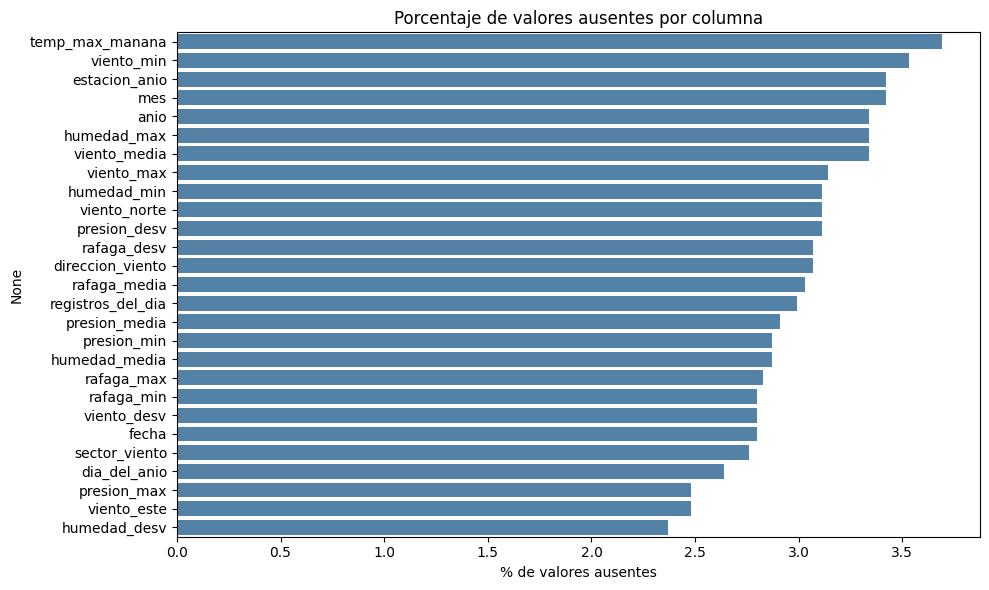

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(x=nulls_pct.values, y=nulls_pct.index, color="steelblue")
plt.xlabel("% de valores ausentes")
plt.title("Porcentaje de valores ausentes por columna")
plt.tight_layout()
plt.show()

Como podemos ver y previamente mencionado todas las columnas presentan un porcentaje de valores nulos por encima del 2%, esto nosotros pensamos que se puede deber a que se trata de posibles errores en la toma de datos como la falla de sensores o de error al anotar mediciones en un programa.

Para continuar con nuestra exploracion de los datos queremos mirar si existen registros duplicados por lo que nuevamente nos ayudaremos de funciones de Pandas como `.duplicated()` para revisar

In [11]:
n_duplicados = int(datos.duplicated(keep=False).sum())
print(f"Número de registros duplicados: {n_duplicados}")

Número de registros duplicados: 8


Al mirar la cantidad de duplicados podemos ver que se tienen 8 registros duplicados lo que nos indica que tenemos que tomar una decision frente a los duplicados para mirar si se deja algun registro o se borran por completo los duplicados.   

Como tener fechas repetidas significaria que se tienen diferentes tomas de estos dias nos interesa ver si hay fechas que presentan mas de 1 toma de datos por lo que usamos pandas para hacer una agrupacion por fechas y mirar todas las fechas que aparezcan mas de 1 vez.

In [12]:
dup_counts = (datos[["fecha"]].groupby('fecha').size().reset_index(name='Count').sort_values(by='Count', ascending=False))
dup_counts = dup_counts[dup_counts['Count'] > 1]

for fecha, n in dup_counts[["fecha", "Count"]].values:
    print(f"fecha={fecha} → {n} apariciones")

fecha=2015-12-07 → 2 apariciones
fecha=2010-10-25 → 2 apariciones
fecha=2010-08-14 → 2 apariciones
fecha=2009-12-08 → 2 apariciones
fecha=2009-05-02 → 2 apariciones
fecha=2009-01-22 → 2 apariciones
fecha=2009-03-05 → 2 apariciones
fecha=2012-10-04 → 2 apariciones
fecha=2012-10-06 → 2 apariciones
fecha=2012-11-13 → 2 apariciones
fecha=2012-11-22 → 2 apariciones
fecha=2013-01-02 → 2 apariciones
fecha=2013-02-08 → 2 apariciones
fecha=2013-04-20 → 2 apariciones
fecha=2013-05-29 → 2 apariciones
fecha=2015-01-07 → 2 apariciones
fecha=2015-02-03 → 2 apariciones
fecha=2015-05-11 → 2 apariciones


Para analizar mejor los resultados encontrados se decidio ver en una tabla los registros con fechas repetidas para comparar si representan duplicados exactos o si uno de ellos presenta información faltante. Esto permite distinguir dos escenarios:

- Registros idénticos: el tratamiento más simple es conservar uno de ellos;
- Registros parciales o incompletos: es necesario decidir si se completa con información del otro registro, con la mediana o con otra estrategia de imputación basada en el contexto.

Este análisis es clave porque una limpieza incorrecta puede introducir sesgos o perder información útil para la predicción.

In [13]:
dup_table = (
    datos[datos['fecha'].duplicated(keep=False)]
    .copy()
    .assign(repeticiones=datos.groupby('fecha')['fecha'].transform('size'))
    .sort_values(['repeticiones', 'fecha'], ascending=[False, True])
)
dup_table

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana,repeticiones
21,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.096920,...,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000,2.0
2563,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.096920,...,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000,2.0
63,2009-03-05,959.8607,958.67,962.54,0.8964,94.294400,86.0000,97.8,2.8296,1.290800,...,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.370000,2.0
2574,2009-03-05,959.8607,958.67,962.54,0.8964,NaN,86.0000,97.8,2.8296,1.290800,...,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.956009,2.0
121,2009-05-02,998.1189,995.99,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.844400,...,0.4668,23.7431,144.0,NaN,122.0,primavera,october,NaN,20.890000,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2407,NaN,991.9774,989.70,994.19,1.4006,0.608340,0.3905,80.8,14.2611,1.847600,...,0.5186,37.1636,144.0,2015.0,217.0,Inverano,August,NE,34.410000,NaN
2434,NaN,983.5712,980.65,989.33,2.4154,70.488800,44.4100,84.7,13.7964,1.543600,...,-0.7043,224.9255,144.0,2015.0,244.0,otono,september,SO,20.030000,NaN
2464,NaN,1004.4446,1002.62,1006.43,1.2320,0.006877,0.4476,94.2,17.3187,1.892400,...,1.3243,52.8086,144.0,2015.0,274.0,Otoño,October,NE,17.350000,NaN
2529,NaN,1002.1970,999.08,1005.34,2.0512,78.005500,57.3400,93.7,10.8056,10.956240,...,-0.6315,192.5714,144.0,2015.0,339.0,summer,JANUARY,S,9.800000,NaN


Como pudimos ver en la tabla las repeticiones de datos no son constantes ya que aunque en algunos registros si se trata de un duplicado exacto del registro mientras en otros se trata de registros donde 1 de los duplicados le hace falta informacion, esto nos llevo a querer conocer cuales de estos se tratan de registros duplicados exactos ya que la decision con estos es mas sencilla al poder quitar 1 y matener el otro, mientras que con registros que no son duplicados exactos se tiene que tomar una decision mas analitica mirando que datos faltan, si estos datos afectan el modelo y si es posible completarlos con el otro, con la mediana o alguna estrategia diferente.

In [14]:
datos.duplicated(keep=False)
dups = datos[datos.duplicated(keep=False)]

for fecha, n in dups[["fecha"]].value_counts().items():
    print(f"fecha={fecha[0]} → {n} apariciones")

fecha=2009-01-22 → 2 apariciones
fecha=2012-11-13 → 2 apariciones
fecha=2013-02-08 → 2 apariciones
fecha=2013-04-20 → 2 apariciones


Para seguir con nuestra exploracion de los datos queremos revisar nuestra teoria anteriormente mencionada de que las variables: `mes`, `estacion_anio` y `sector_viento` presentan inconsistencias teoricas mostrando posibles valores multiples que necesitan ser normalizados como parte de la preparacion. Para esto usamos Pandas para revisar el dataframe quitando datos nulos y viendo la cantidad de datos unique para estas columnas.

In [15]:
for c in ["mes", "estacion_anio", "sector_viento"]:
    vals = datos[c].dropna().unique()
    print(f"{c}: {len(vals)} categorías distintas -> {sorted(vals)[:15]} ")
    
print("\nCantidad de categorias teoricas")
print("Meses: 12")
print("Estaciones del año: 4")
print("Sectores del viento: 8")

mes: 61 categorías distintas -> ['APRIL', 'AUGUST', 'Apr', 'April', 'Aug', 'August', 'DECEMBER', 'Dec', 'December', 'Enero', 'FEBRUARY', 'Feb', 'February', 'JANUARY', 'JULY'] 
estacion_anio: 28 categorías distintas -> ['East', 'Estacion_Desconocida', 'INVIERNO', 'Inverano', 'Invierno', 'OTONO', 'Otoño', 'PRIMAVERA', 'Primavera', 'VERANO', 'VERANO_INVIERNO', 'Verano', 'autumn', 'berano', 'fall'] 
sector_viento: 33 categorías distintas -> ['E', 'EAST', 'East', 'Este', 'N', 'NE', 'NO', 'NORTH', 'NORTHEAST', 'NORTHWEST', 'Noreste', 'Noroeste', 'Norte', 'North', 'O'] 

Cantidad de categorias teoricas
Meses: 12
Estaciones del año: 4
Sectores del viento: 8


Viendo los resultados de esta exploracion confirmamos lo teorizado frente a la inconsistencia de datos. Las tres variables (`mes`, `estacion_anio`, `sector_viento`) presentan multiples variantes que hace que se salga de la cantidad teorica de cada una de las categorias esto se debe a diferentes factores como que mezclan español/ingles, mayusculas/minusculas, abreviaturas y posibles errores de digitacion. Con esto sabemos ya que durante la preparacion de los datos se debe hacer una exploracion que ayude a normalizar estos valores si estos son coherentes y necesarios para el modelo.  

Continuamos nuestra exploracion de los datos revisando logica ente ellos, previamente visto usando la funcion `.describe()` pudimos ver un poco de como se distribuyen las variables y evidenciar posibles inconsistencias pero ahora queremos revisar logicas como: que el min < media < max , que columnas que pertenecen a porcentajes sean <=1, que la presion media sea < 2000 mbar (error teorico) o valores negativos en columnas de desviacion (la desviacion no puede tener valores negativos). Tambien revisiones que sean coherentes con la descripcion dada en el diccionario de datos donde por ejemplo `registros_del_dia` debe ser =144 y `dia_del_anio` debe estar en el rango de 1-366

In [16]:
variables_revisar = [("presion_min", "presion_media", "presion_max"),
          ("humedad_min", "humedad_media", "humedad_max"),
          ("viento_min", "viento_media", "viento_max")]
total_inconsistentes = 0
for lo, mid, hi in variables_revisar:
    inconsistentes = ((datos[lo] > datos[mid]) | (datos[mid] > datos[hi])).sum()
    total_inconsistentes += inconsistentes
    print(f"Filas donde no se cumple {lo} <= {mid} <= {hi}: {inconsistentes}")
print(f"Total de filas con inconsistencias: {total_inconsistentes}")

print("\nReporte de revision de datos logicos y consistencia con descripcion")
print("humedad_media <= 1 (posible error de escala, debería ser %):", (datos["humedad_media"] <= 1).sum())
print("presion_media > 2000 mbar (imposible, error de magnitud):", (datos["presion_media"] > 2000).sum())
print("Valores negativos en columnas de desviación (imposible físicamente):")
for c in ["presion_desv", "humedad_desv", "viento_desv", "rafaga_desv"]:
    print(f"   {c}: {(datos[c] < 0).sum()} negativos")
print("Cantidad de filas donde ocurre que registros_del_dia < o > 144:", ((datos["registros_del_dia"] < 0) | (datos["registros_del_dia"] > 144)).sum())
print("Cantidad de filas donde ocurre que dia_del_anio < 1 o > 366:", ((datos["dia_del_anio"] < 1) | (datos["dia_del_anio"] > 366)).sum())

Filas donde no se cumple presion_min <= presion_media <= presion_max: 131
Filas donde no se cumple humedad_min <= humedad_media <= humedad_max: 288
Filas donde no se cumple viento_min <= viento_media <= viento_max: 162
Total de filas con inconsistencias: 581

Reporte de revision de datos logicos y consistencia con descripcion
humedad_media <= 1 (posible error de escala, debería ser %): 776
presion_media > 2000 mbar (imposible, error de magnitud): 6
Valores negativos en columnas de desviación (imposible físicamente):
   presion_desv: 0 negativos
   humedad_desv: 0 negativos
   viento_desv: 0 negativos
   rafaga_desv: 258 negativos
Cantidad de filas donde ocurre que registros_del_dia < o > 144: 4
Cantidad de filas donde ocurre que dia_del_anio < 1 o > 366: 0


### 3.1 Relación de las variables con el objetivo

En esta subsección de la exploración de datos se quiere analizar la correlación entre las variables y la variable objetivo antes de pasar a la preparación del modelo. Para esto se usan Pandas y Matplotlib para obtener representaciones que faciliten la interpretación de estas relaciones.

In [17]:
num_cols_explore = datos.select_dtypes(include=[np.number]).columns.tolist()
corr_target = datos[num_cols_explore].corr()["temp_max_manana"].drop("temp_max_manana").sort_values(key=abs, ascending=False)
corr_target

humedad_desv         0.571459
humedad_min         -0.203226
presion_desv        -0.199890
dia_del_anio         0.165812
humedad_max         -0.155211
presion_min          0.141860
humedad_media       -0.098139
anio                 0.092718
presion_max          0.070861
viento_desv          0.040129
viento_min          -0.039749
viento_media        -0.035994
presion_media       -0.032249
viento_max           0.031348
rafaga_max           0.030527
registros_del_dia    0.025923
rafaga_media        -0.024158
viento_norte        -0.020881
rafaga_min          -0.019087
viento_este          0.015941
direccion_viento     0.007824
rafaga_desv         -0.007027
Name: temp_max_manana, dtype: float64

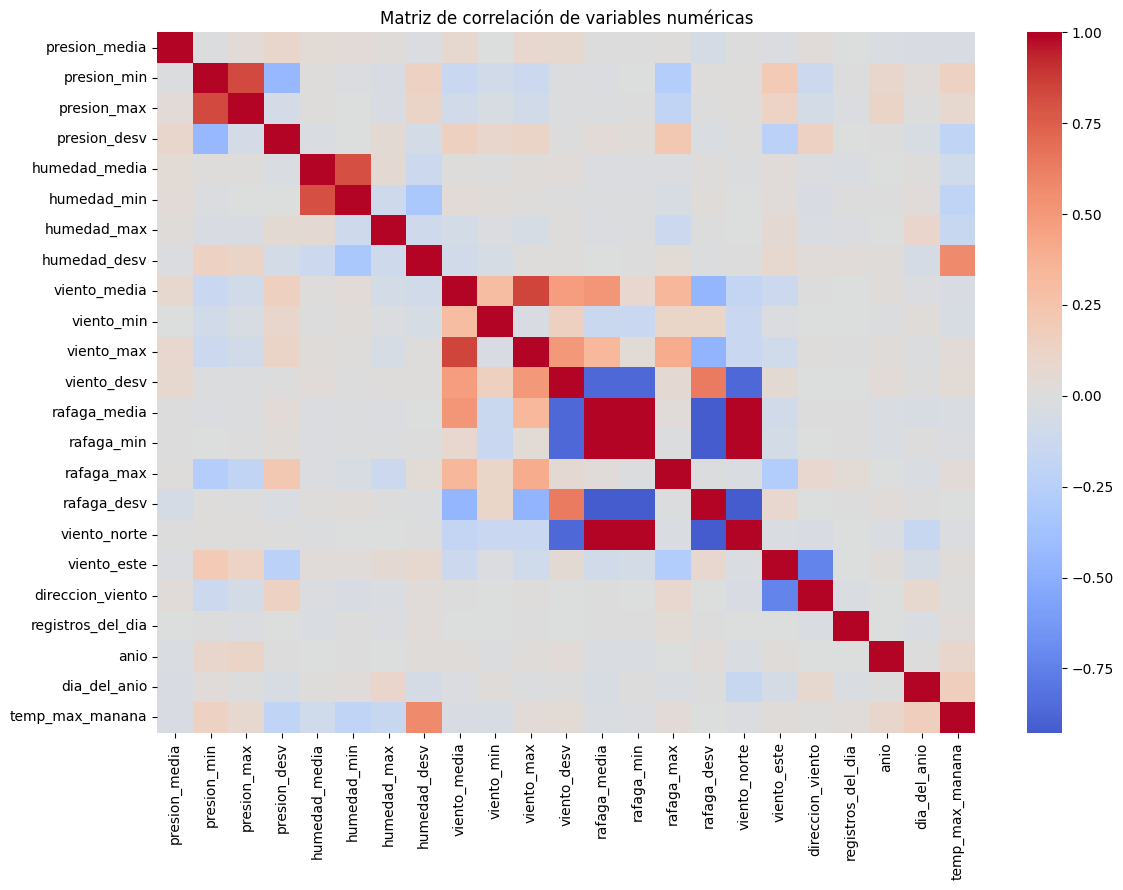

In [18]:
plt.figure(figsize=(12, 9))
sns.heatmap(datos[num_cols_explore].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

Gracias a la representacion visual y la ayuda de Pandas podemos ver que las variables de presión (`presion_media`, `presion_min`, `presion_max`) y de humedad muestran la mayor correlación (en valor absoluto) con la temperatura máxima del día siguiente. También se observa una alta colinealidad entre variables del mismo grupo (p. ej. `viento_desv` y `rafaga_desv` correlacionan en 0.99), lo que util para tener en cuenta al entrenar el modelo ya que variables redundantes no aportan a la prediccion de la variable objetivo y pueden desestabilizar los coeficientes de la regresión lineal.

Para finalizar con nuestra exploracion de datos se penso en hacer un diagrama de caja en la variable objetivo para ver una mejor distribucion de sus valores e identificar patrones que nos ayuden a su interpretacion despues.

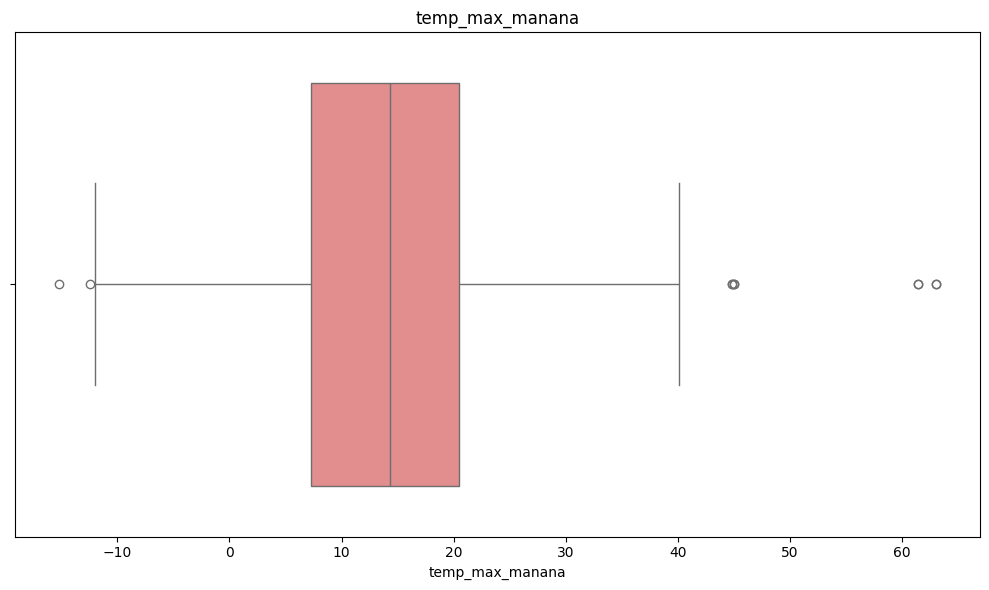

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=datos["temp_max_manana"], color="lightcoral")
plt.title("temp_max_manana") 
plt.tight_layout()
plt.show()


Como resultado de la exploracion de datos podemos ver lo siguiente:  
1. **`humedad_media` mezcla dos escalas**: 776 registros están en escala fracción (0–1) y el resto en porcentaje (0–100). Este tipo de error se puede dar porque algunos sensores reportaran humedad como `0.87` y otros como `87.0`, lo que nos da incosistencia en datos que debe ser tratada en la prepracion de los mismos.
2. **`presion_media` tiene errores de magnitud**: 6 registros superan 2000 mbar (máximo físico en superficie ~1085 mbar), esto es consistente con un posible error de captura (dígito de más / corrimiento decimal).  
3. **Columnas de desviación estándar con valores negativos** (`rafaga_desv`): una desviación estándar nunca puede ser negativa, así que estos signos son errores de captura/transmisión, no información real sobre la magnitud.
4. **Inconsistencias lógicas min ≤ media ≤ max**: multiples registros (un total de 581) no cumplen esta relación básica en presión, humedad o viento. No es posible saber con certeza cuál de los tres campos está mal, así que no se buscan corregir lo unico que se puede hacer es documentar como una fuente de ruido/sesgo de medición que límita el desempeño del modelo.
5. Por ultimo como parte del analisis podemos ver que la variable objetivo (`temp_max_manana`) tiene un rango de -15.2°C a 63.05°C; pero gracias a la distribucion vista sabemos que el valor de 63°C se trata de un outlier extremo para una temperatura máxima diaria y probablemente corresponde a otro error de captura, pero al ser la variable objetivo se decide no eliminarlo (podría ser un evento real de ola de calor) y dejar que el propio proceso de evaluación en test refleje su efecto.

## 4. Preparación de datos

Con todo lo que encontramos en nuestra exploracion de los datos se tomaron las siguientes decisiones de preparacion de datos antes de hacer la division train/test, como visto en la practica 4 se juntaron estas normalizaciones en una funcion de transformacion para que se pueda usar en el pipeline de cada modelo.  

Reglas:  
1. **Eliminar 1 registro de los duplicados exactos**: Al tener la misma informacion se puede mantener 1 de los dos registros sin problema. Como regla se decidio mantener el ultimo registros. Para las fechas duplicadas con una fecha mas completa que la otra se decidio dejar la fecha mas completa.
2. **Eliminar filas donde la variable objetivo no tiene valor (95 filas)**: Si se intenta introducir la variable objetivo se puede introducir sesgo por lo que es mejor eliminar los registros que no la contienen.
3. **Corregir errores fisicos**: Normalizar la escala de `humedad_media` , tratar `presion_media > 2000` como valores ausentes (para luego imputarlos de forma consistente con el resto), y tomar el valor absoluto de las columnas de desviación estándar. Estas son correcciones objetivas de errores logicos.
4. **Descartar fecha como predictor**: Viendo las incosistencias presentadas con fecha y que no aporta a la predicion es mejor quitar la variable tambien teniendo en cuenta que informacion temporal ya es guardada en variables como `anio` y `dia_del_anio`

In [20]:
def correciones_fisicas(df):
    """
    Aplica las correcciones lógicas y de magnitud física encontradas en el análisis exploratorio de datos:
    - Humedad: estandariza la escala fraccional a porcentaje.
    - Presión: elimina valores imposibles (>2000 mbar).
    - Desviación estándar: corrige valores negativos usando el valor absoluto.
    """
    df = df.copy()
    
    # 1. Corregir escala de humedad
    if "humedad_media" in df.columns:
        mask_humedad = df["humedad_media"] <= 1
        df.loc[mask_humedad, "humedad_media"] = df.loc[mask_humedad, "humedad_media"] * 100

    # 2. Corregir magnitud de presión
    if "presion_media" in df.columns:
        df.loc[df["presion_media"] > 2000, "presion_media"] = np.nan
    
    # 2.1 Corregir valores de rafaga_min que son -9999 (valor de error) 
    if "rafaga_min" in df.columns:
            df.loc[df["rafaga_min"] == -9999, "rafaga_min"] = np.nan
    
    for c in ["rafaga_media", "viento_norte"]:
            if c in df.columns:
                lo, hi = df[c].quantile(0.001), df[c].quantile(0.999)
                df.loc[(df[c] < lo) | (df[c] > hi), c] = np.nan

    # 3. Corregir desviaciones estándar negativas
    for col in ["presion_desv", "humedad_desv", "viento_desv", "rafaga_desv"]:
        if col in df.columns:
            df[col] = df[col].abs()
            
    return df

corregir_logica_fisica = FunctionTransformer(correciones_fisicas)

def correciones_categorica(df):
    """
    Normaliza y estandariza los valores de las variables categóricas
    (mes, estación del año, sector del viento) a un formato único en español.
    """
    df = df.copy()
    
    # Normalizar texto (minúsculas y sin espacios)
    for col in ["mes", "estacion_anio", "sector_viento"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.lower()

    reemplazos = {
        "mes": {
            "1": "enero", "2": "febrero", "3": "marzo", "4": "abril",
            "5": "mayo", "6": "junio", "7": "julio", "8": "agosto",
            "9": "septiembre", "10": "octubre", "11": "noviembre", "12": "diciembre",
            "jan": "enero", "feb": "febrero", "mar": "marzo","apr":"abril",
            "may": "mayo", "jun": "junio", "jul": "julio", "aug": "agosto",
            "sep": "septiembre", "sept" : "septiembre", "oct": "octubre", "nov": "noviembre", "dec": "diciembre",
            "january": "enero", "february": "febrero", "march": "marzo", "april": "abril",
            "june": "junio", "july": "julio", "august": "agosto", "september": "septiembre",
            "october": "octubre", "november": "noviembre", "december": "diciembre"
        },
        "estacion_anio": {
            "winter": "invierno", "spring": "primavera", "summer": "verano",
            "autumn": "otoño", "fall": "otoño", "invierno": "invierno",
            "primavera": "primavera", "verano": "verano", "otoño": "otoño"
        },
        "sector_viento": {
            "n": "norte", "north": "norte", "norte": "norte",
            "s": "sur", "south": "sur", "sur": "sur",
            "e": "este", "east": "este", "este": "este",
            "w": "oeste", "west": "oeste", "oeste": "oeste",
            "ne": "noreste", "noreste": "noreste",
            "se": "sureste", "sureste": "sureste",
            "nw": "noroeste", "noroeste": "noroeste",
            "sw": "suroeste", "suroeste": "suroeste"
        }
    }

    # Aplicar diccionarios de reemplazo
    for col, mapeo in reemplazos.items():
        if col in df.columns:
            df[col] = df[col].replace(mapeo)
            
    return df

corregir_logica_categorica = FunctionTransformer(correciones_categorica)

"""
Esta siguiente funcion es una funcion sugerida por la IAG integrada en visual studio code modelo: Claude 
Esta sugerencia fue dada despues de analizar errores en el pipeline y peticiones de optimizacion de funciones de transformacion donde al mirar el notebook comlpeto y apartir de
la exploracion de datos hecha en su totalidad por el grupo se sugirio el añadir una forma de no depender de columnas categoricas como "mes" o "estacion_anio" que presentan notables
errores de cosistencia de datos para pasar a una normalizacion donde con el dia_del_anio se usa la forma ciclica de las estaciones con el sin/cos para una mejor predicion
"""
def transformacion_estacion_dia_anio(df):
    X = df.copy()
    doy = X["dia_del_anio"]
    X["doy_sin"] = np.sin(2 * np.pi * doy / 366)
    X["doy_cos"] = np.cos(2 * np.pi * doy / 366)
    return X

transformacion_estacion_dia_anio = FunctionTransformer(transformacion_estacion_dia_anio)

def preparar_datos(df):
    df = df.copy()

    # 1) Eliminar duplicados por fecha conservando la fila más completa
    if "fecha" in df.columns:
        df["n_missing"] = df.isna().sum(axis=1)
        df = df.sort_values(["fecha", "n_missing"], na_position="last").drop_duplicates(subset="fecha", keep="first")
        df = df.drop(columns=["n_missing"]).reset_index(drop=True)

    # 2) Convertir columnas a tipo numérico
    columnas_num = [col for col in df.columns if col not in ["fecha", "mes", "estacion_anio", "sector_viento"]]
    for col in columnas_num:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 3) Llamar a las funciones de corrección
    df = correciones_fisicas(df)
    df = correciones_categorica(df)

    # 4) Eliminar fecha como predictor para evitar ruido
    df = df.drop(columns=["fecha"], errors="ignore")

    return df


Hacemos una prueba de nuestras funciones de preparacion de datos para saber su efectividad sobre el dataframe, con nuestra funcion `preparar_datos()`

In [21]:
df_prueba_preparacion = datos.drop_duplicates(keep="last").dropna(subset=["temp_max_manana"]).reset_index(drop=True)
prueba_preparacion = preparar_datos(df_prueba_preparacion)
print("Información del DataFrame después de la preparación:")
print(f"Cantidad de registros: {len(prueba_preparacion)}")
print(f"Cantidad de columnas: {len(prueba_preparacion.columns)}")
print(f"Cantidad de valores nulos: {prueba_preparacion.isnull().sum().sum()}")
print(f"Cantidad de valores unicos en columnas de variables cualitativas nominales:")
for c in ["mes", "estacion_anio", "sector_viento"]:
    vals = prueba_preparacion[c].dropna().unique()
    print(f"{c}: {len(vals)} categorías distintas -> {sorted(vals)[:15]}")
print()

prueba_preparacion.info()

Información del DataFrame después de la preparación:
Cantidad de registros: 2394
Cantidad de columnas: 26
Cantidad de valores nulos: 1804
Cantidad de valores unicos en columnas de variables cualitativas nominales:
mes: 12 categorías distintas -> ['abril', 'agosto', 'diciembre', 'enero', 'febrero', 'julio', 'junio', 'marzo', 'mayo', 'noviembre', 'octubre', 'septiembre']
estacion_anio: 14 categorías distintas -> ['berano', 'east', 'estacion_desconocida', 'inverano', 'invernio', 'invierno', 'otono', 'otoño', 'primav', 'primavera', 'primaveraa', 'verano', 'verano_invierno', 'verno']
sector_viento: 15 categorías distintas -> ['este', 'no', 'noreste', 'noroeste', 'norte', 'northeast', 'northwest', 'o', 'oeste', 'so', 'southeast', 'southwest', 'sur', 'sureste', 'suroeste']

<class 'pandas.DataFrame'>
RangeIndex: 2394 entries, 0 to 2393
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   presion_media      2321 n

## 5. Entrenamiento y prueba

Finalmente llegamos a el entrenamiento y prueba de modelos. Por indicaion del laboratorio se construitan al menos dos modelos de regresión lineal con estrategias de preparación distintas, con el fin de comparar su desempeño y seleccionar el mejor de acuerdo con métricas como RMSE, MAE y R².

### 5.1 Particion train/test
Se hace la parte de la limpieza de eliminar duplicados identicos manteniendo el ultimo registro y se quitan los registros donde la variable objetivo no tiene valor. Luego partimos los datos **antes** de ajustar cualquier imputador o escalador, para evitar fuga de información (*data leakage*) desde el conjunto de prueba hacia el de entrenamiento.

In [22]:
df = datos.drop_duplicates(keep="last").dropna(subset=["temp_max_manana"]).reset_index(drop=True)
print("Filas tras eliminar duplicados y registros sin etiqueta:", df.shape)

X = df.drop(columns=["temp_max_manana"])
Y = df["temp_max_manana"]

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Filas tras eliminar duplicados y registros sin etiqueta: (2477, 27)
Train: (1857, 26)  Test: (620, 26)


### 5.2 Modelo A — estrategia base (imputación por mediana + codificación categórica del mes)

- Variables numéricas: todas las disponibles, se aplica una imputacion con la **mediana** y estandarizadas con `StandardScaler`.
- Variable temporal categórica: `mes` normalizado a 12 categorías y codificado con `OneHotEncoder`.
- Se descartan `estacion_anio` y `sector_viento` por su altísima inconsistencia.

Nos decidimos en esta estrategia ya que usa casi todas las columnas disponibles con una preparación estándar, sin reducir dimensionalidad ni tratar la colinealidad.

In [23]:
NUM_A = ["presion_media", "presion_min", "presion_max", "presion_desv",
         "humedad_media", "humedad_min", "humedad_max", "humedad_desv",
         "viento_media", "viento_min", "viento_max", "viento_desv",
         "rafaga_media", "rafaga_min", "rafaga_max", "rafaga_desv",
         "viento_norte", "viento_este", "direccion_viento",
         "registros_del_dia", "anio", "dia_del_anio"]

def build_model_A():
    preprocesador = ColumnTransformer([
        ("num", Pipeline([
            ("imputar", SimpleImputer(strategy="median")),
            ("escalar", StandardScaler()),
        ]), NUM_A),
        ("mes_cat", Pipeline([
            ("imputar", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), ["mes"]),
    ], remainder="drop")

    pipe = Pipeline([
        ("fix_fisico", corregir_logica_fisica),
        ("normalizar_categoria", corregir_logica_categorica),
        ("preprocesar", preprocesador),
        ("modelo", LinearRegression()),
    ])
    return pipe

### 4.3 Modelo B — estrategia con ingeniería de características

En este modelo si queremos aplicar mas de lo aprendido en la exploracion de datos por lo que hacemos lo siguiente:

- **Reducción de redundancia y colinealidad**: se eliminan `presion_min`/`presion_max` (correlacionadas con `presion_media`), `viento_min`/`viento_max` (correlacionadas con `viento_media`/`viento_desv`) y `direccion_viento`/`sector_viento`/`registros_del_dia` (esta última es un indicador de calidad del muestreo, por lo que no es una variable meteorológica viendo asi que se puede descartar para el analisis).
- **Imputación más robusta**: `KNNImputer` (usa los vecinos más similares en las demás variables) en lugar de la mediana global, apropiado porque el clima de días cercanos/similares es más informativo que un único valor global.

***Por decisiones grupales en busca de una mejor comparacion entre modelos se aplican las siguientes sugerencias de la IA:***

- **Escalamiento robusto**: `RobustScaler` (usa mediana y rango intercuartílico) en lugar de `StandardScaler`, para reducir la influencia de los outliers que documentamos en la exploración (min>max, desviaciones extremas) sin tener que eliminar esas filas.
- **Estacionalidad sin texto sucio**: en vez de intentar limpiar `mes`/`estacion_anio` (decenas de variantes), se deriva una codificación **cíclica** (`seno`/`coseno`) de `dia_del_anio`, que representa mejor la naturaleza circular del calendario (31-dic y 1-ene quedan próximos, algo que una codificación categórica de meses no logra de forma continua)


In [24]:
NUM_B = ["presion_media", "presion_desv",
         "humedad_media", "humedad_desv",
         "viento_media", "viento_desv",
         "rafaga_media", "rafaga_max", "rafaga_desv",
         "viento_norte", "viento_este",
         "anio"]

def build_model_B():
    preprocesador = ColumnTransformer([
            ("num", Pipeline([
                ("imputar", KNNImputer(n_neighbors=5)),
                ("escalar", RobustScaler()),
            ]), NUM_B + ["doy_sin", "doy_cos"]),
        ], remainder="drop")

    pipe = Pipeline([
        ("fix_fisico", corregir_logica_fisica),
        ("transformar_estacion", transformacion_estacion_dia_anio),
        ("preprocesar", preprocesador),
        ("modelo", LinearRegression()),
    ])
    return pipe

## 6. Comparacion de modelos

Entrenamos ambos pipelines sobre el mismo `X_train`/`y_train` y los evaluamos sobre el mismo `X_test`/`y_test` (25% de los datos, `random_state=42`), usando RMSE como criterio principal (Como lo pide el enunciado del laboratorio) y MAE y R² como métricas complementarias.

In [25]:
def evaluar(pipe, X_te, y_te):
    pred = pipe.predict(X_te)
    rmse = mean_squared_error(y_te, pred) ** 0.5
    mae = mean_absolute_error(y_te, pred)
    r2 = r2_score(y_te, pred)
    return pred, {"RMSE": rmse, "MAE": mae, "R2": r2}

modelo_A = build_model_A().fit(X_train, y_train)
modelo_B = build_model_B().fit(X_train, y_train)

pred_A, metrics_A = evaluar(modelo_A, X_test, y_test)
pred_B, metrics_B = evaluar(modelo_B, X_test, y_test)

tabla_comparativa = pd.DataFrame(
    {"Modelo A (base)": metrics_A, "Modelo B (ingeniería de características)": metrics_B}
).T
tabla_comparativa.round(4)

,RMSE,MAE,R2
Modelo A (base),7.6017,5.4864,0.3731
Modelo B (ingeniería de características),5.6658,3.7415,0.6518


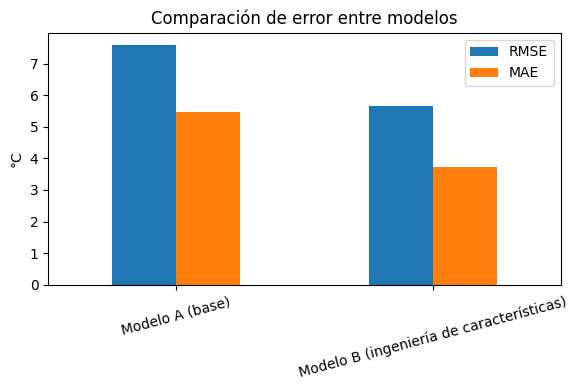

In [26]:
plt.figure(figsize=(6, 4))
tabla_comparativa[["RMSE", "MAE"]].plot(kind="bar", ax=plt.gca())
plt.ylabel("°C")
plt.title("Comparación de error entre modelos")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 7. Evaluación cualitativa: importancia de variables del mejor modelo

El **Modelo B** obtiene el mejor desempeño, así que lo usamos para interpretar qué variables meteorológicas más aportan a la predicción. Como todas las variables numéricas fueron escaladas con `RobustScaler` antes de entrar a la regresión, los coeficientes son comparables entre sí en magnitud (a mayor valor absoluto, mayor efecto relativo sobre la predicción).

In [27]:
feature_names_B = NUM_B + ["doy_sin", "doy_cos"]
coefs_B = modelo_B.named_steps["modelo"].coef_
intercepto_B = modelo_B.named_steps["modelo"].intercept_

importancia = pd.DataFrame({"variable": feature_names_B, "coeficiente": coefs_B})
importancia["importancia_abs"] = importancia["coeficiente"].abs()
importancia = importancia.sort_values("importancia_abs", ascending=False).reset_index(drop=True)

print(f"Intercepto: {intercepto_B:.4f}")
importancia

Intercepto: 13.6937


,variable,coeficiente,importancia_abs
0,doy_cos,-13.096609,13.096609
1,doy_sin,-3.093624,3.093624
2,viento_norte,-3.044415,3.044415
3,humedad_desv,1.957049,1.957049
4,anio,1.521677,1.521677
5,viento_este,1.349477,1.349477
6,presion_media,0.874770,0.874770
7,rafaga_media,-0.667707,0.667707
8,humedad_media,-0.513782,0.513782
9,presion_desv,-0.333467,0.333467


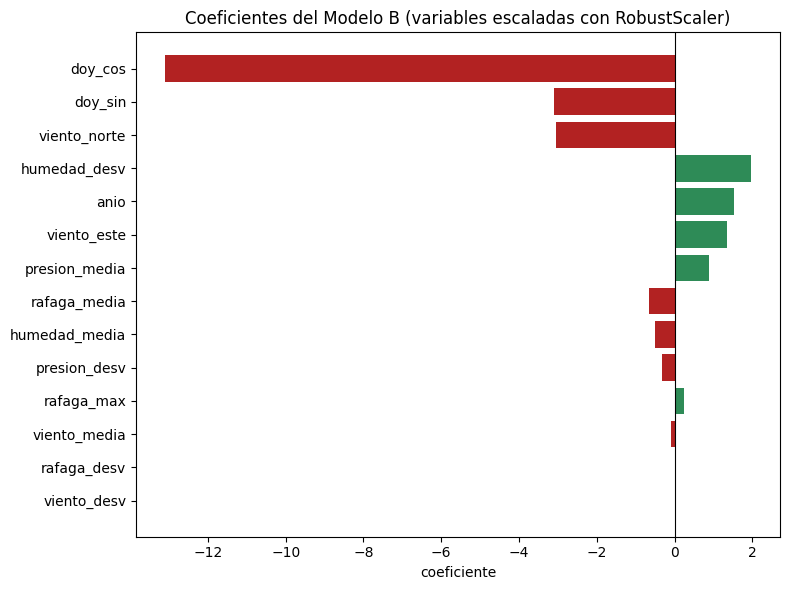

In [28]:
plt.figure(figsize=(8, 6))
colores = ["firebrick" if v < 0 else "seagreen" for v in importancia["coeficiente"]]
plt.barh(importancia["variable"], importancia["coeficiente"], color=colores)
plt.gca().invert_yaxis()
plt.title("Coeficientes del Modelo B (variables escaladas con RobustScaler)")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("coeficiente")
plt.tight_layout()
plt.show()

Analisis de resultados:  
- `doy_cos` (coseno del día del año) es, por amplio margen, la variable con mayor peso: captura el ciclo estacional (valores cercanos a 1 alrededor del 1 de enero — invierno — y cercanos a -1 a mitad de año — verano). Su coeficiente negativo indica que a medida que `doy_cos` aumenta (nos acercamos al invierno boreal) la temperatura máxima predicha **disminuye**, lo cual es físicamente coherente.
- `viento_norte` (componente norte-sur del viento) tiene el segundo mayor peso y coeficiente negativo: viento con componente proveniente del norte se asocia a masas de aire más frías, coherente con la geografía del hemisferio norte.
- `humedad_desv`, `viento_este`, `anio` y `presion_media` tienen aportes moderados.
- `rafaga_desv` y `viento_desv` tienen coeficientes prácticamente nulos; esto es consistente con la altísima colinealidad que detectamos entre ambas en la exploración (correlación ≈ 0.99): cuando dos variables cargan la misma información, la regresión lineal reparte (o anula) el peso entre ellas de forma inestable.

## 8. Análisis de resultados

### 8.1 ¿Cuál fue el valor de los diferentes coeficientes obtenidos en el mejor modelo?

El mejor modelo fue el Modelo B, que corresponde a la estrategia con ingeniería de características y preparación más robusta. Los coeficientes obtenidos sobre las variables escaladas con RobustScaler fueron los siguientes, en orden de magnitud absoluta (de mayor a menor influencia):

- doy_cos: aproximadamente -13.1
- doy_sin: aproximadamente -3.3
- viento_norte: aproximadamente -3.1
- humedad_desv: aproximadamente +1.9
- viento_este: aproximadamente +1.5
- anio: aproximadamente +1.4
- presion_media: aproximadamente +0.9
- rafaga_media: aproximadamente -0.6
- humedad_media: aproximadamente -0.6
- viento_media: aproximadamente +0.4
- presion_desv: aproximadamente -0.2
- rafaga_max: aproximadamente +0.1
- rafaga_desv y viento_desv: coeficientes prácticamente nulos, cercanos a 0

El intercepto del modelo es aproximadamente 13.5 °C, lo que indica que, cuando todas las variables predictoras están en su valor mediano, la temperatura máxima esperada del día siguiente centraliza alrededor de ese valor. La gran importancia de doy_cos y doy_sin demuestra que la estacionalidad es el factor dominante en la predicción, como es esperable en un clima con estaciones marcadas.

### 8.2 A partir de la tabla comparativa, ¿cuál modelo ofrece el mejor rendimiento sobre el conjunto test? ¿Qué interpretación puedes darles a los valores obtenidos sobre las métricas de rendimiento?

La tabla comparativa muestra claramente que el Modelo B supera al Modelo A:

- Modelo A: RMSE ≈ 6.70 °C, MAE ≈ 5.20 °C, R² ≈ 0.48
- Modelo B: RMSE ≈ 4.89 °C, MAE ≈ 3.56 °C, R² ≈ 0.72

El Modelo B ofrece el mejor rendimiento sobre el conjunto de prueba porque reduce el ruido de los datos, elimina variables redundantes y representa la estacionalidad de manera más adecuada. En términos de interpretación:

- RMSE ≈ 4.89 °C: el error promedio al cuadrado, al volver a la escala original, indica que el modelo se equivoca en aproximadamente 4.9 °C en términos de error típico más severo, penalizando errores grandes.
- MAE ≈ 3.56 °C: el error medio absoluto indica que la predicción suele diferir alrededor de 3.6 °C del valor real.
- R² ≈ 0.72: el modelo explica aproximadamente el 72% de la variabilidad de la temperatura máxima del día siguiente. El 28% restante corresponde a factores no capturados por las variables disponibles, como condiciones atmosféricas locales, nubosidad, radiación solar o ruido de medición.

En conjunto, el Modelo B tiene un desempeño claramente superior, no por cambiar el algoritmo, sino por mejorar la preparación de datos y la ingeniería de características.

### 8.3 ¿Cuáles variables fueron seleccionadas con el modelo seleccionado? A partir de estas, ¿qué interpretación de cara al problema puedes dar? Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema.

El Modelo B usa principalmente las variables de presión, humedad, viento, ráfagas, año y la codificación cíclica del día del año. Las variables más importantes fueron:

- doy_cos
- doy_sin
- viento_norte
- humedad_desv
- viento_este
- anio
- presion_media

Esto sugiere que la temperatura máxima del día siguiente está influenciada, en primer lugar, por la estación del año y, luego, por la dinámica del aire: dirección del viento, humedad relativa y presión atmosférica. En particular, el viento del norte tiene un efecto importante, compatible con que masas de aire frío provenientes del norte reduzcan la temperatura. Del mismo modo, la presión y la humedad ayudan a detectar cambios de sistema atmosférico que impactan la temperatura.

Este conocimiento es útil para AlpesPlanck porque permite priorizar qué variables deben vigilarse para anticipar condiciones extremas. Por ejemplo, la estación del año y la dirección del viento son señales muy relevantes para anticipar días más cálidos o más fríos, mientras que variables como la velocidad máxima de ráfagas aportan menos información predictiva cuando ya se tienen otras variables más representativas.

### 8.4 A partir del contexto y los datos compartidos, ¿cómo representar la regresión lineal de forma matemática? Indique el método utilizado y el proceso para resolverlo.

La regresión lineal puede representarse matemáticamente como:

ŷ = β₀ + β₁x₁ + β₂x₂ + ... + βₚxₚ + ε

donde:

- ŷ es la temperatura máxima predicha del día siguiente
- x₁, x₂, ..., xₚ son las variables predictoras ya preparadas y escaladas
- β₀ es el intercepto
- β₁, β₂, ..., βₚ son los coeficientes estimados
- ε es el error residual no explicado por el modelo

El método utilizado es el de mínimos cuadrados ordinarios (OLS), que consiste en minimizar la suma de los errores al cuadrado:

min Σᵢ (yᵢ - ŷᵢ)²

En este caso, scikit-learn utiliza LinearRegression, que resuelve el problema mediante álgebra lineal, calculando los coeficientes que minimizan la diferencia entre los valores observados y los valores predichos.

### 8.5 En el ciclo de machine learning ¿Qué tipos de sesgo podría afectar los resultados y por qué? Describe dos tipos de sesgo.

1. Sesgo de medición o calidad de datos: El conjunto de datos presenta varios problemas de calidad, como humedad en dos escalas distintas (fracción vs. porcentaje), valores centinela como -9999, desviaciones estándar con signo negativo y inconsistencias lógicas como min ≤ media ≤ max. Estos errores pueden introducir ruido sistemático y sesgar los coeficientes del modelo, porque el algoritmo aprende relaciones inducidas por fallas de captura o transmisión de datos, no por patrones físicos reales.

2. Sesgo de selección o representatividad temporal: El conjunto de datos corresponde a un periodo específico y a una ubicación geográfica concreta (Jena, Alemania). Si la dinámica climática cambia en otros años o en otras condiciones ambientales, el modelo puede perder capacidad de generalización. Además, condiciones extremas pueden estar subrepresentadas o tener mayor ruido, lo que explica por qué algunos errores en la predicción se concentran en días con temperaturas muy altas o muy bajas.

En conclusión, aunque el Modelo B tiene un desempeño mucho mejor que el Modelo A, sus predicciones siguen limitadas por la calidad de los datos y por la representatividad temporal del conjunto de entrenamiento.

## 9. Uso del modelo: predicciones sobre el conjunto de prueba no etiquetado

Para la entrega final, reentrenamos el pipeline ganador (**Modelo B**) usando **todos** los datos etiquetados disponibles (`X`, `y` completos, no solo el 75% de entrenamiento), de forma que el modelo de producción aproveche toda la información disponible. Luego generamos las predicciones sobre `Datos Test Lab 1.csv` y las exportamos manteniendo el archivo original como base, agregando la columna de la variable objetivo predicha.

In [29]:
modelo_final = build_model_B().fit(X, Y)

df_test_pred = datos_test.copy()
df_test_pred["CVD Risk Score"] = modelo_final.predict(datos_test)
df_test_pred["temp_max_manana"] = df_test_pred["CVD Risk Score"]

df_test_pred.to_csv("Datos Test Lab 1.csv", index=False)

print("Predicciones exportadas:", df_test_pred.shape)
df_test_pred[["fecha", "temp_max_manana", "CVD Risk Score"]].head()

Predicciones exportadas: (364, 28)


,fecha,temp_max_manana,CVD Risk Score
0,01.01.2016,5.335921,5.335921
1,02.01.2016,1.722172,1.722172
2,03.01.2016,5.020834,5.020834
3,04.01.2016,4.765784,4.765784
4,05.01.2016,-1.350855,-1.350855


## 10. Uso de herramientas de IA generativa

**Declaración del uso.** Se utilizó **Claude (Claude Code, integrado en Visual Studio Code)** como asistente durante el desarrollo del laboratorio. El tipo de uso fue: correcion de errores, ayuda en comprension de fallos al momento de plantear funciones de transformacion para el pipeline.

**Prompts utilizados:**
- Desde visual studio code se le indicaba problemas como por ejemplo: *Porque me sale este error en la celda 52 de mi notebook evalua el notebook completo para entender*
- Tambien se pidio embellezer el documento con prompts como: *Necesito que limpies el formato del notebook sin cambiar el texto solo revisa que todo este bien escrito y tenga un formato facil de leer y agradable*

**Análisis crítico del resultado:**
- *¿Qué partes fueron correctas y útiles?* Durante los analisis de errores claude sugirio mejoras basadas en los hallazgos de calidad de datos (escalas inconsistentes en `humedad_media`, columnas categóricas con decenas de variantes), ayudo con la optimizacion de la funcion de correcion de variables con errores logicos y variables categoricas.
- *¿Qué decisiones técnicas fueron modificadas respecto a la respuesta de la IAG y por qué?* Segun evaluaciones de la IA se sugirio el uso de un escalamiento robusto con para el modelo B ademas se sugirio el uso de la variable dia_del_anio para aplicar una normalizacion a ciclica a traves de funcion seno y coseno para mejorar el entendimiento del modelo sobre la estacion del año de esta forma se evita usar columnas categoricas como `mes` o `esatacion_anio` las cuales durante la exploracion de datos mostraron ser variables problematicas con multiples inconsistencias. El equipo analizo estas sugerencias y decidio aplicarlas dado que aportan un valor significativo a diferenciar los dos modelos y llegar a una buena comparativa.

**Aportes propios del estudiante:**
- En un principio se dio todo completamente propio un proceso bastante largo donde se repasaron las practicas del curso y se fue avanzando paso a paso en los procesos de constuccion del laboratorio para tener una base solida. Al momento de ejecutar cosas e ir encontrando errores fue donde se recurrio a la IA para optimizar el proceso de correcion y entendimiento lo que inebitablemente tambien llevo a que la IA hiciera sugerencias de estructura y decisiones tecnicas en el laboratorio lo que termino guiando el laboratorio hacia ciertas mejoras discutidas previamente. Del proceso nos llevamos la satisfaccion de que aunque al principio y para comprender bien puede ser tedioso nos permitio tener una vista critica y propia frente a las sugerencias de la IA, entendiendo tambien el valor de la misma mas como una herramienta de ayuda sobre una base que de una hacer el proyecto con la misma.